In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:

df = pd.read_csv("D:\Infosys_Springboard\CreditPathAI\CreditPathAI\data\Loan_default.csv")
df.head()


<>:1: SyntaxWarning: invalid escape sequence '\I'
<>:1: SyntaxWarning: invalid escape sequence '\I'
C:\Users\srila\AppData\Local\Temp\ipykernel_21536\2299096657.py:1: SyntaxWarning: invalid escape sequence '\I'
  df = pd.read_csv("D:\Infosys_Springboard\CreditPathAI\CreditPathAI\data\Loan_default.csv")


,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


In [3]:
print("Shape of dataset")
print("Shape of dataset:", df.shape)

Shape of dataset
Shape of dataset: (148670, 34)


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  object 
 3   Gender                     148670 non-null  object 
 4   approv_in_adv              147762 non-null  object 
 5   loan_type                  148670 non-null  object 
 6   loan_purpose               148536 non-null  object 
 7   Credit_Worthiness          148670 non-null  object 
 8   open_credit                148670 non-null  object 
 9   business_or_commercial     148670 non-null  object 
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges            10

In [5]:
print("Summary statistics for numerical columns")
print(df.describe().T)

Summary statistics for numerical columns
                         count           mean            std           min  \
ID                    148670.0   99224.500000   42917.476598  24890.000000   
year                  148670.0    2019.000000       0.000000   2019.000000   
loan_amount           148670.0  331117.743997  183909.310127  16500.000000   
rate_of_interest      112231.0       4.045476       0.561391      0.000000   
Interest_rate_spread  112031.0       0.441656       0.513043     -3.638000   
Upfront_charges       109028.0    3224.996127    3251.121510      0.000000   
term                  148629.0     335.136582      58.409084     96.000000   
property_value        133572.0  497893.465696  359935.315562   8000.000000   
income                139520.0    6957.338876    6496.586382      0.000000   
Credit_Score          148670.0     699.789103     115.875857    500.000000   
LTV                   133572.0      72.746457      39.967603      0.967478   
Status                1

In [6]:
print("Summary statistics for categorical columns")
print(df.describe(include=['object', 'category']).T)

Summary statistics for categorical columns
                            count unique       top    freq
loan_limit                 145326      2        cf  135348
Gender                     148670      4      Male   42346
approv_in_adv              147762      2     nopre  124621
loan_type                  148670      3     type1  113173
loan_purpose               148536      4        p3   55934
Credit_Worthiness          148670      2        l1  142344
open_credit                148670      2      nopc  148114
business_or_commercial     148670      2     nob/c  127908
Neg_ammortization          148549      2   not_neg  133420
interest_only              148670      2   not_int  141560
lump_sum_payment           148670      2  not_lpsm  145286
construction_type          148670      2        sb  148637
occupancy_type             148670      3        pr  138201
Secured_by                 148670      2      home  148637
total_units                148670      4        1U  146480
credit_type  

In [7]:
print("Missing value count")
print(df.isnull().sum())

Missing value count
ID                               0
year                             0
loan_limit                    3344
Gender                           0
approv_in_adv                  908
loan_type                        0
loan_purpose                   134
Credit_Worthiness                0
open_credit                      0
business_or_commercial           0
loan_amount                      0
rate_of_interest             36439
Interest_rate_spread         36639
Upfront_charges              39642
term                            41
Neg_ammortization              121
interest_only                    0
lump_sum_payment                 0
property_value               15098
construction_type                0
occupancy_type                   0
Secured_by                       0
total_units                      0
income                        9150
credit_type                      0
Credit_Score                     0
co-applicant_credit_type         0
age                            200


***SUMMARY STATS***

In [8]:
print("DESCRIPTIVE STATISTICS OF INCOME COLUMN")
print(f'mean: {df["income"].mean()}')
print(f'median: {df["income"].median()}')
print(f'standard deviation: {df["income"].std()}')
print(f'minimum: {df["income"].min()}')
print(f'maximum: {df["income"].max()}')
print(f'range: {df["income"].max() - df["income"].min()}')
print(f'variance: {df["income"].var()}')
print(f'skewness: {df["income"].skew()}')

DESCRIPTIVE STATISTICS OF INCOME COLUMN
mean: 6957.338876146789
median: 5760.0
standard deviation: 6496.586382220254
minimum: 0.0
maximum: 578580.0
range: 578580.0
variance: 42205634.621649645
skewness: 17.307695079866924


***DISTRIBUTION PLOTS FOR KEY FEATURES***

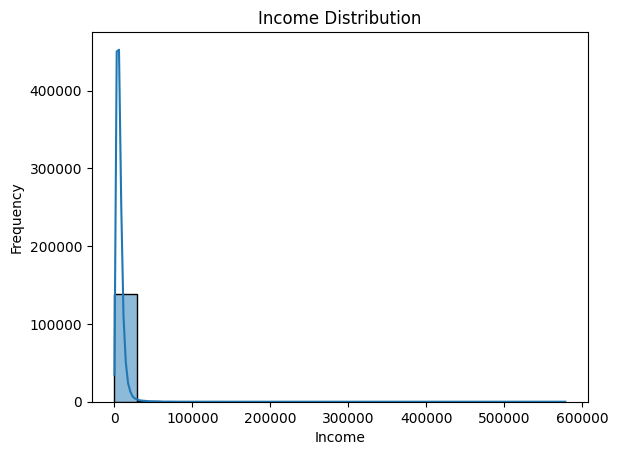

In [9]:
sns.histplot(df['income'], bins=20,kde=True,fill=True)
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.title('Income Distribution')
plt.show()

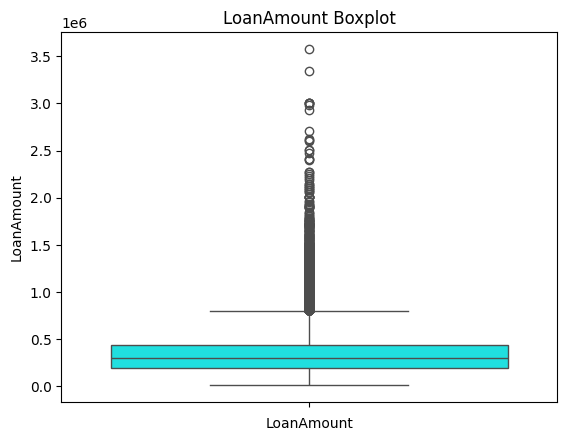

In [10]:
sns.boxplot(df['loan_amount'],color='aqua')
plt.xlabel('LoanAmount')
plt.ylabel('LoanAmount')
plt.title('LoanAmount Boxplot')
plt.show()

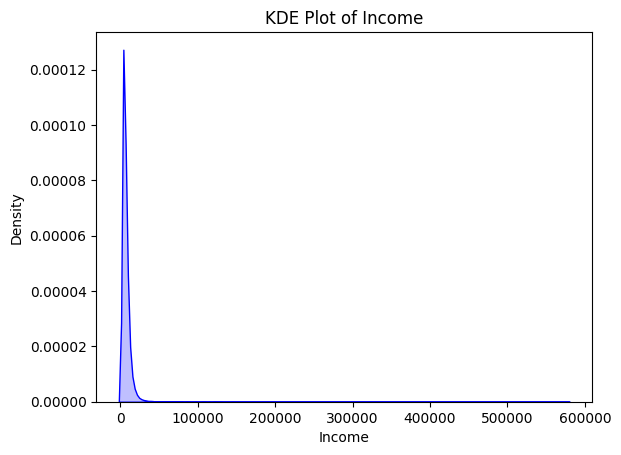

In [11]:
sns.kdeplot(df['income'], fill=True, color="blue")
plt.title("KDE Plot of Income")
plt.xlabel("Income")
plt.ylabel("Density")
plt.show()

Distribution of Target Variable

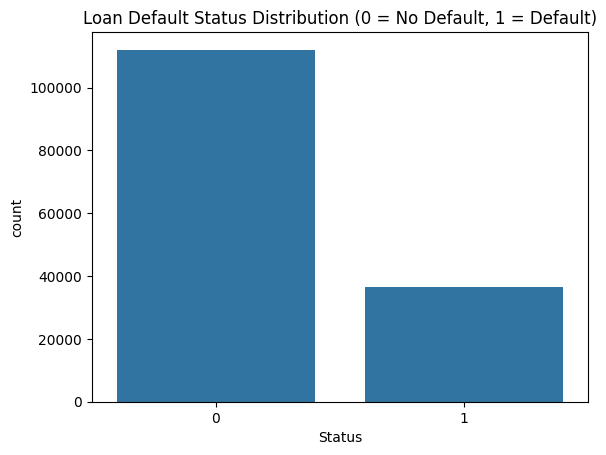

In [12]:
sns.countplot(x="Status", data=df)
plt.title("Loan Default Status Distribution (0 = No Default, 1 = Default)")
plt.show()

***CORRELATION HEATMAP***

In [13]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
numeric_cols

Index(['ID', 'year', 'loan_amount', 'rate_of_interest', 'Interest_rate_spread',
       'Upfront_charges', 'term', 'property_value', 'income', 'Credit_Score',
       'LTV', 'Status', 'dtir1'],
      dtype='object')

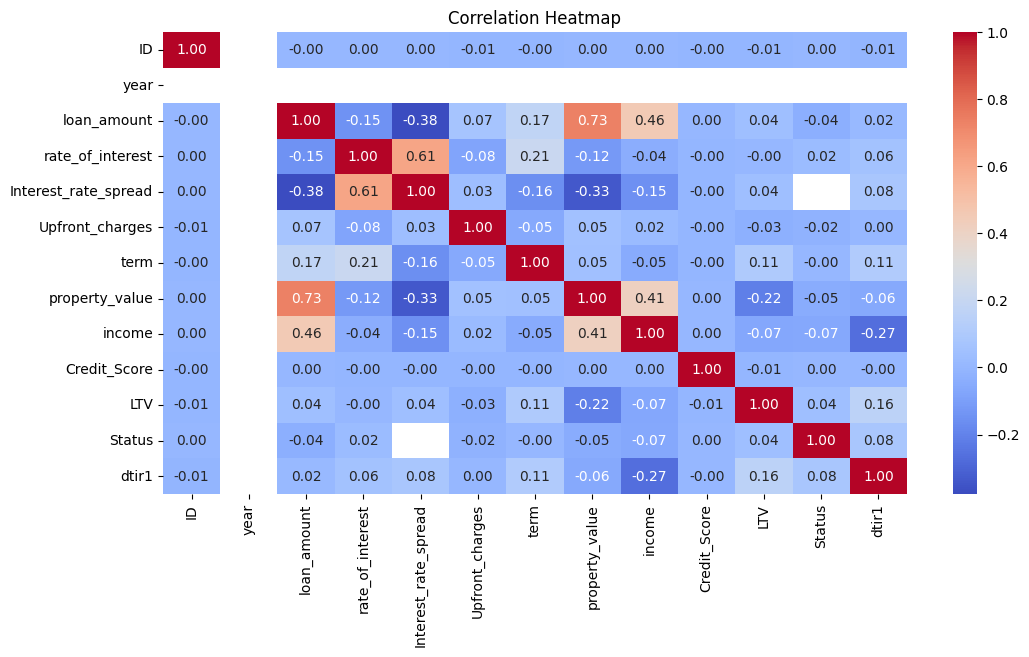

In [14]:
corr = df[numeric_cols].corr()
plt.figure(figsize=(12,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

***OUTLIER DETECTION***

In [15]:
print("OUTLIER COUNT IN EACH NUMERIC COLUMN")
outliers = {}

for col in numeric_cols:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5*IQR
  upper_bound = Q3 + 1.5*IQR
  outlier_count = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
  outliers[col] = outlier_count

outliers

OUTLIER COUNT IN EACH NUMERIC COLUMN


{'ID': 0,
 'year': 0,
 'loan_amount': 1895,
 'rate_of_interest': 856,
 'Interest_rate_spread': 445,
 'Upfront_charges': 2880,
 'term': 26944,
 'property_value': 5266,
 'income': 6546,
 'Credit_Score': 0,
 'LTV': 1882,
 'Status': 36639,
 'dtir1': 2013}

***MISSING VALUES***

In [16]:
df.isnull().sum()


ID                               0
year                             0
loan_limit                    3344
Gender                           0
approv_in_adv                  908
loan_type                        0
loan_purpose                   134
Credit_Worthiness                0
open_credit                      0
business_or_commercial           0
loan_amount                      0
rate_of_interest             36439
Interest_rate_spread         36639
Upfront_charges              39642
term                            41
Neg_ammortization              121
interest_only                    0
lump_sum_payment                 0
property_value               15098
construction_type                0
occupancy_type                   0
Secured_by                       0
total_units                      0
income                        9150
credit_type                      0
Credit_Score                     0
co-applicant_credit_type         0
age                            200
submission_of_applic

C:\Users\srila\AppData\Local\Temp\ipykernel_21536\3364650231.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing.index, y=missing.values, palette="viridis")


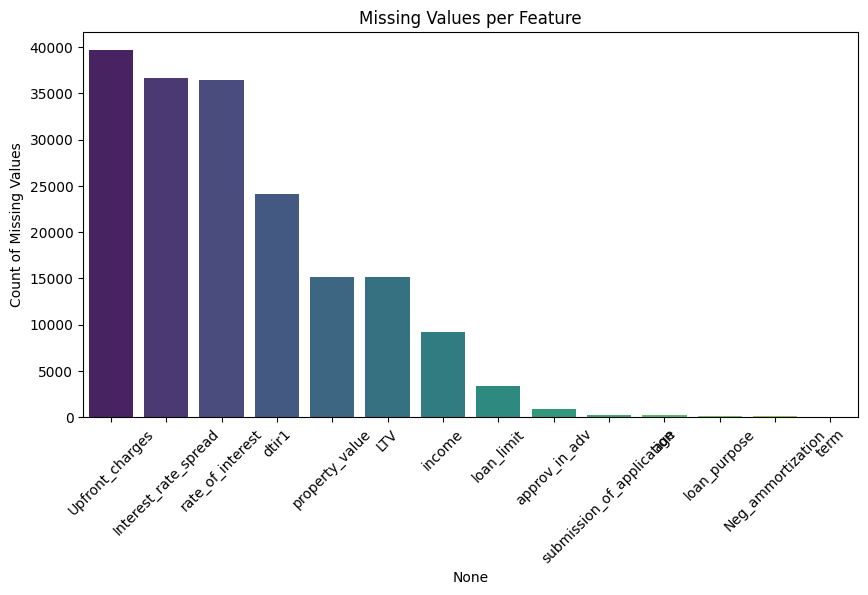

In [17]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=missing.index, y=missing.values, palette="viridis")
plt.title("Missing Values per Feature")
plt.ylabel("Count of Missing Values")
plt.xticks(rotation=45)
plt.show()

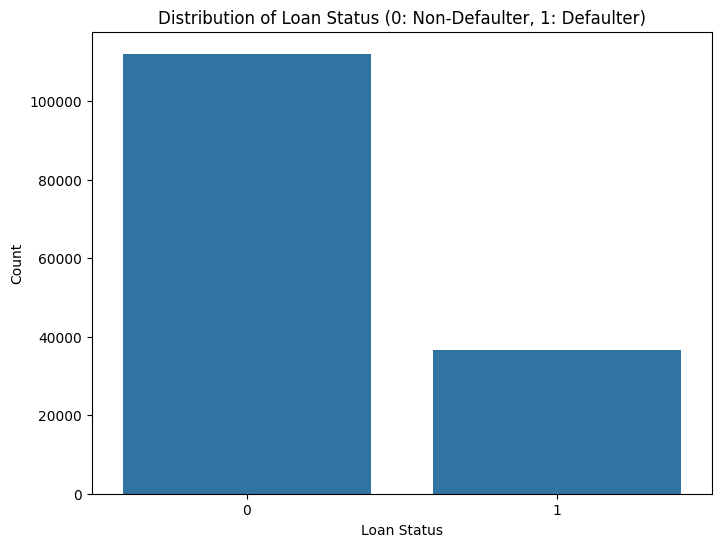


Loan Status Counts:
Status
0    112031
1     36639
Name: count, dtype: int64

Loan Status Proportions:
Status
0    75.355485
1    24.644515
Name: proportion, dtype: float64


In [18]:
# Plot the distribution of the target variable
plt.figure(figsize=(8, 6))
sns.countplot(x='Status', data=df)
plt.title('Distribution of Loan Status (0: Non-Defaulter, 1: Defaulter)')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.show()

# Print the exact counts
print("\nLoan Status Counts:")
print(df['Status'].value_counts())
print("\nLoan Status Proportions:")
print(df['Status'].value_counts(normalize=True) * 100)